<a href="https://colab.research.google.com/github/srinivascoventry/mekapatis-fnal-project/blob/main/Srinivas_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import os

BASE_DIR = "/content/drive/MyDrive/ISIC2018_Task3"
EXTRACTED_DIR = os.path.join(BASE_DIR, "Untitled folder")

print("BASE_DIR exists:", os.path.exists(BASE_DIR))
print("EXTRACTED_DIR exists:", os.path.exists(EXTRACTED_DIR))
print("\nFolders inside extracted dir:")
print("\n".join(os.listdir(EXTRACTED_DIR)))

BASE_DIR exists: True
EXTRACTED_DIR exists: True

Folders inside extracted dir:
ISIC2018_Task3_Validation_Input
ISIC2018_Task3_Validation_GroundTruth
ISIC2018_Task3_Training_GroundTruth
ISIC2018_Task3_Training_Input


**Data Pre-Processing**

In [4]:
folders = [
    "splits",
    "models",
    "outputs"
]

for f in folders:
    path = os.path.join(BASE_DIR, f)
    os.makedirs(path, exist_ok=True)

print("Created/verified folders:")
for f in folders:
    print("-", os.path.join(BASE_DIR, f))

Created/verified folders:
- /content/drive/MyDrive/ISIC2018_Task3/splits
- /content/drive/MyDrive/ISIC2018_Task3/models
- /content/drive/MyDrive/ISIC2018_Task3/outputs


In [5]:
TRAIN_IMG_DIR = os.path.join(EXTRACTED_DIR, "ISIC2018_Task3_Training_Input")
VAL_IMG_DIR   = os.path.join(EXTRACTED_DIR, "ISIC2018_Task3_Validation_Input")

print("TRAIN_IMG_DIR exists:", os.path.exists(TRAIN_IMG_DIR))
print("VAL_IMG_DIR exists  :", os.path.exists(VAL_IMG_DIR))

print("\nTrain folder sample:", os.listdir(TRAIN_IMG_DIR)[:5])
print("Val folder sample  :", os.listdir(VAL_IMG_DIR)[:5])

TRAIN_IMG_DIR exists: True
VAL_IMG_DIR exists  : True

Train folder sample: ['ISIC_0033343.jpg', 'ISIC_0033331.jpg', 'ISIC_0033349.jpg', 'ISIC_0033322.jpg', 'ISIC_0033326.jpg']
Val folder sample  : ['ISIC_0034502.jpg', 'ISIC_0034487.jpg', 'ISIC_0034500.jpg', 'ISIC_0034496.jpg', 'ISIC_0034505.jpg']


In [6]:
import glob
import os

train_jpgs = glob.glob(os.path.join(TRAIN_IMG_DIR, "*.jpg"))
val_jpgs   = glob.glob(os.path.join(VAL_IMG_DIR, "*.jpg"))

print("Train JPG count:", len(train_jpgs))
print("Val JPG count  :", len(val_jpgs))

print("\nExample train file:", train_jpgs[0] if len(train_jpgs)>0 else "None")
print("Example val file  :", val_jpgs[0] if len(val_jpgs)>0 else "None")

Train JPG count: 10018
Val JPG count  : 193

Example train file: /content/drive/MyDrive/ISIC2018_Task3/Untitled folder/ISIC2018_Task3_Training_Input/ISIC_0033343.jpg
Example val file  : /content/drive/MyDrive/ISIC2018_Task3/Untitled folder/ISIC2018_Task3_Validation_Input/ISIC_0034502.jpg


In [7]:
import glob
import os

TRAIN_GT_DIR = os.path.join(EXTRACTED_DIR, "ISIC2018_Task3_Training_GroundTruth")
VAL_GT_DIR   = os.path.join(EXTRACTED_DIR, "ISIC2018_Task3_Validation_GroundTruth")

train_csv_paths = glob.glob(os.path.join(TRAIN_GT_DIR, "*.csv"))
val_csv_paths   = glob.glob(os.path.join(VAL_GT_DIR, "*.csv"))

print("Train GT CSV files:", train_csv_paths)
print("Val GT CSV files  :", val_csv_paths)

Train GT CSV files: ['/content/drive/MyDrive/ISIC2018_Task3/Untitled folder/ISIC2018_Task3_Training_GroundTruth/ISIC2018_Task3_Training_GroundTruth.csv']
Val GT CSV files  : ['/content/drive/MyDrive/ISIC2018_Task3/Untitled folder/ISIC2018_Task3_Validation_GroundTruth/ISIC2018_Task3_Validation_GroundTruth.csv']


In [8]:
import pandas as pd

train_csv_path = train_csv_paths[0]
val_csv_path   = val_csv_paths[0]

train_gt = pd.read_csv(train_csv_path)
val_gt   = pd.read_csv(val_csv_path)

print("Train GT shape:", train_gt.shape)
print("Val GT shape  :", val_gt.shape)

print("Train columns:", train_gt.columns.tolist())
print("\nTrain head:\n", train_gt.head())
print("\nVal head:\n", val_gt.head())

Train GT shape: (10015, 8)
Val GT shape  : (193, 8)
Train columns: ['image', 'MEL', 'NV', 'BCC', 'AKIEC', 'BKL', 'DF', 'VASC']

Train head:
           image  MEL   NV  BCC  AKIEC  BKL   DF  VASC
0  ISIC_0024306  0.0  1.0  0.0    0.0  0.0  0.0   0.0
1  ISIC_0024307  0.0  1.0  0.0    0.0  0.0  0.0   0.0
2  ISIC_0024308  0.0  1.0  0.0    0.0  0.0  0.0   0.0
3  ISIC_0024309  0.0  1.0  0.0    0.0  0.0  0.0   0.0
4  ISIC_0024310  1.0  0.0  0.0    0.0  0.0  0.0   0.0

Val head:
           image  MEL   NV  BCC  AKIEC  BKL   DF  VASC
0  ISIC_0034321  0.0  1.0  0.0    0.0  0.0  0.0   0.0
1  ISIC_0034322  0.0  1.0  0.0    0.0  0.0  0.0   0.0
2  ISIC_0034323  0.0  0.0  1.0    0.0  0.0  0.0   0.0
3  ISIC_0034324  0.0  1.0  0.0    0.0  0.0  0.0   0.0
4  ISIC_0034325  0.0  1.0  0.0    0.0  0.0  0.0   0.0


In [9]:
import os


train_map = {os.path.splitext(os.path.basename(p))[0]: p for p in train_jpgs}
val_map   = {os.path.splitext(os.path.basename(p))[0]: p for p in val_jpgs}

train_gt["img_path"] = train_gt["image"].map(train_map)
val_gt["img_path"]   = val_gt["image"].map(val_map)

print("Missing train images:", train_gt["img_path"].isna().sum())
print("Missing val images  :", val_gt["img_path"].isna().sum())

print("\nTrain sample paths:\n", train_gt[["image","img_path"]].head())
print("\nVal sample paths:\n", val_gt[["image","img_path"]].head())

Missing train images: 0
Missing val images  : 0

Train sample paths:
           image                                           img_path
0  ISIC_0024306  /content/drive/MyDrive/ISIC2018_Task3/Untitled...
1  ISIC_0024307  /content/drive/MyDrive/ISIC2018_Task3/Untitled...
2  ISIC_0024308  /content/drive/MyDrive/ISIC2018_Task3/Untitled...
3  ISIC_0024309  /content/drive/MyDrive/ISIC2018_Task3/Untitled...
4  ISIC_0024310  /content/drive/MyDrive/ISIC2018_Task3/Untitled...

Val sample paths:
           image                                           img_path
0  ISIC_0034321  /content/drive/MyDrive/ISIC2018_Task3/Untitled...
1  ISIC_0034322  /content/drive/MyDrive/ISIC2018_Task3/Untitled...
2  ISIC_0034323  /content/drive/MyDrive/ISIC2018_Task3/Untitled...
3  ISIC_0034324  /content/drive/MyDrive/ISIC2018_Task3/Untitled...
4  ISIC_0034325  /content/drive/MyDrive/ISIC2018_Task3/Untitled...


In [10]:
import numpy as np

label_cols = train_gt.columns[1:8].tolist()   # ['MEL','NV','BCC','AKIEC','BKL','DF','VASC']
print("Label columns:", label_cols)

# Converting one-hot to class name and numeric label
train_gt["label_name"] = train_gt[label_cols].idxmax(axis=1)
train_gt["label"] = train_gt[label_cols].values.argmax(axis=1)

val_gt["label_name"] = val_gt[label_cols].idxmax(axis=1)
val_gt["label"] = val_gt[label_cols].values.argmax(axis=1)

print("\nTrain label sample:")
print(train_gt[["image","label_name","label"]].head())

print("\nVal label sample:")
print(val_gt[["image","label_name","label"]].head())

print("\nTrain class distribution:")
print(train_gt["label_name"].value_counts())

Label columns: ['MEL', 'NV', 'BCC', 'AKIEC', 'BKL', 'DF', 'VASC']

Train label sample:
          image label_name  label
0  ISIC_0024306         NV      1
1  ISIC_0024307         NV      1
2  ISIC_0024308         NV      1
3  ISIC_0024309         NV      1
4  ISIC_0024310        MEL      0

Val label sample:
          image label_name  label
0  ISIC_0034321         NV      1
1  ISIC_0034322         NV      1
2  ISIC_0034323        BCC      2
3  ISIC_0034324         NV      1
4  ISIC_0034325         NV      1

Train class distribution:
label_name
NV       6705
MEL      1113
BKL      1099
BCC       514
AKIEC     327
VASC      142
DF        115
Name: count, dtype: int64


In [11]:
from sklearn.model_selection import train_test_split
import os

model_df = train_gt[["image", "img_path", "label", "label_name"]].copy()
print("model_df shape:", model_df.shape)
model_df.head()

model_df shape: (10015, 4)


,image,img_path,label,label_name
0,ISIC_0024306,/content/drive/MyDrive/ISIC2018_Task3/Untitled...,1,NV
1,ISIC_0024307,/content/drive/MyDrive/ISIC2018_Task3/Untitled...,1,NV
2,ISIC_0024308,/content/drive/MyDrive/ISIC2018_Task3/Untitled...,1,NV
3,ISIC_0024309,/content/drive/MyDrive/ISIC2018_Task3/Untitled...,1,NV
4,ISIC_0024310,/content/drive/MyDrive/ISIC2018_Task3/Untitled...,0,MEL


In [12]:
# 70% train, 30% temp
df_train, df_temp = train_test_split(
    model_df,
    test_size=0.30,
    stratify=model_df["label"],
    random_state=42
)

# Split temp into 15% val and 15% test
df_val, df_test = train_test_split(
    df_temp,
    test_size=0.50,
    stratify=df_temp["label"],
    random_state=42
)

print("Train:", df_train.shape, "Val:", df_val.shape, "Test:", df_test.shape)

# Save splits
split_dir = os.path.join(BASE_DIR, "splits")
os.makedirs(split_dir, exist_ok=True)

df_train.to_csv(os.path.join(split_dir, "train_internal.csv"), index=False)
df_val.to_csv(os.path.join(split_dir, "val_internal.csv"), index=False)
df_test.to_csv(os.path.join(split_dir, "test_internal.csv"), index=False)

print("Saved to:", split_dir)

Train: (7010, 4) Val: (1502, 4) Test: (1503, 4)
Saved to: /content/drive/MyDrive/ISIC2018_Task3/splits


In [13]:
print("Train distribution:\n", df_train["label_name"].value_counts())
print("\nVal distribution:\n", df_val["label_name"].value_counts())
print("\nTest distribution:\n", df_test["label_name"].value_counts())

Train distribution:
 label_name
NV       4693
MEL       779
BKL       769
BCC       360
AKIEC     229
VASC       99
DF         81
Name: count, dtype: int64

Val distribution:
 label_name
NV       1006
MEL       167
BKL       165
BCC        77
AKIEC      49
VASC       21
DF         17
Name: count, dtype: int64

Test distribution:
 label_name
NV       1006
MEL       167
BKL       165
BCC        77
AKIEC      49
VASC       22
DF         17
Name: count, dtype: int64


**EDA**

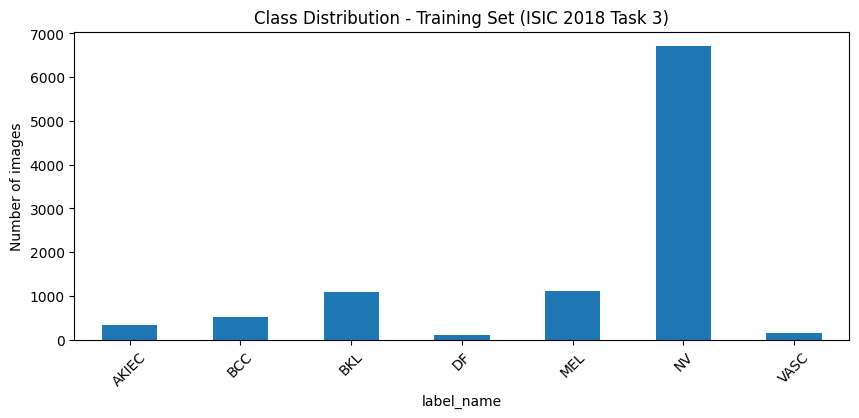

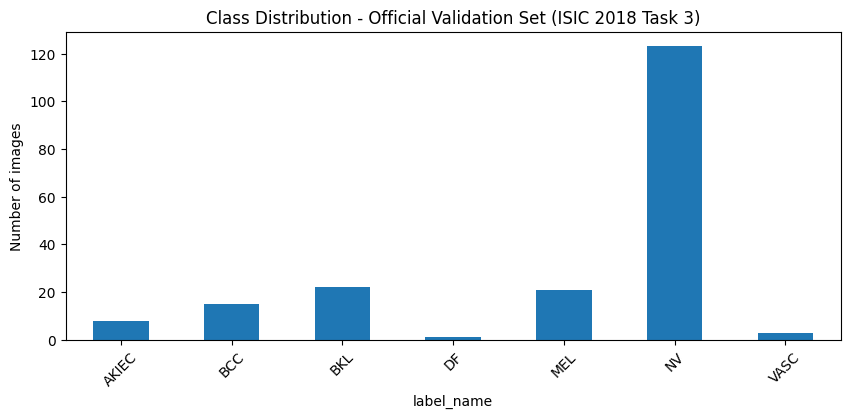

In [14]:
import matplotlib.pyplot as plt

train_counts = train_gt["label_name"].value_counts().sort_index()
val_counts   = val_gt["label_name"].value_counts().reindex(train_counts.index).fillna(0)

plt.figure(figsize=(10,4))
train_counts.plot(kind="bar")
plt.title("Class Distribution - Training Set (ISIC 2018 Task 3)")
plt.ylabel("Number of images")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10,4))
val_counts.plot(kind="bar")
plt.title("Class Distribution - Official Validation Set (ISIC 2018 Task 3)")
plt.ylabel("Number of images")
plt.xticks(rotation=45)
plt.show()

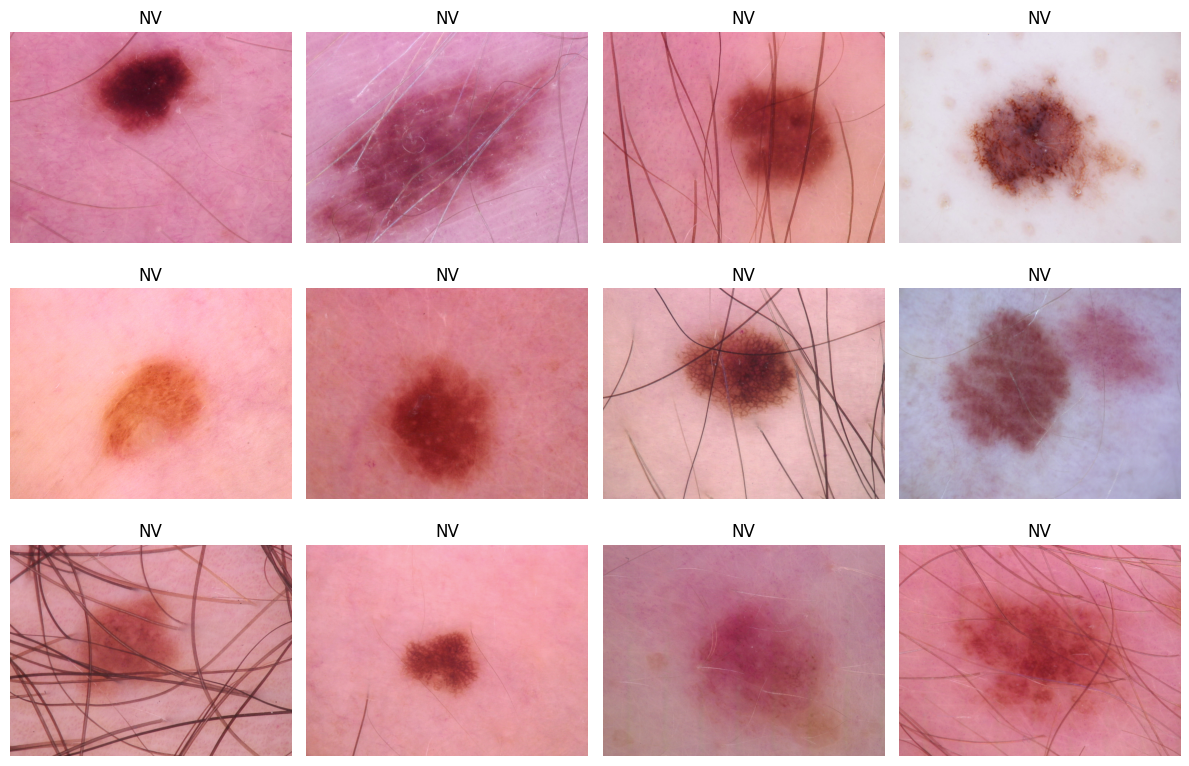

In [15]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def show_samples(df, n=12):
    sample_df = df.sample(n, random_state=42).reset_index(drop=True)
    plt.figure(figsize=(12,8))

    for i in range(n):
        row = sample_df.iloc[i]
        img = cv2.imread(row["img_path"])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(3, 4, i+1)
        plt.imshow(img)
        plt.title(row["label_name"])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_samples(train_gt, n=12)

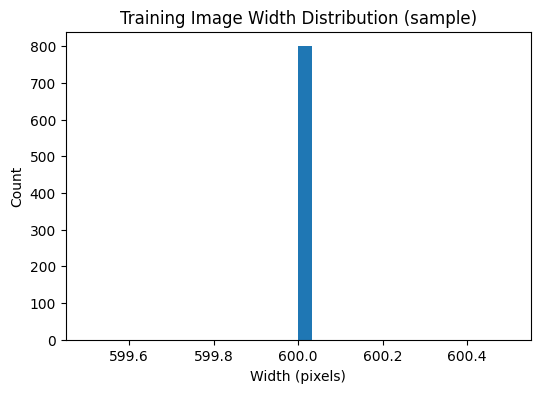

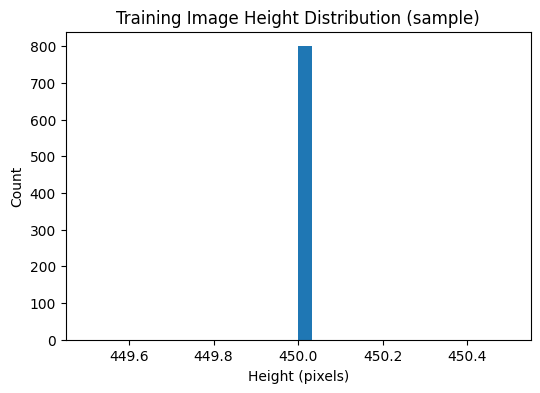

In [16]:
import pandas as pd
import cv2
import matplotlib.pyplot as plt

def get_image_sizes(df, sample_size=800):
    sample_df = df.sample(min(sample_size, len(df)), random_state=42)
    widths, heights = [], []

    for p in sample_df["img_path"]:
        img = cv2.imread(p)
        h, w = img.shape[:2]
        widths.append(w)
        heights.append(h)

    return pd.DataFrame({"width": widths, "height": heights})

sizes_df = get_image_sizes(train_gt, sample_size=800)

plt.figure(figsize=(6,4))
plt.hist(sizes_df["width"], bins=30)
plt.title("Training Image Width Distribution (sample)")
plt.xlabel("Width (pixels)")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(6,4))
plt.hist(sizes_df["height"], bins=30)
plt.title("Training Image Height Distribution (sample)")
plt.xlabel("Height (pixels)")
plt.ylabel("Count")
plt.show()

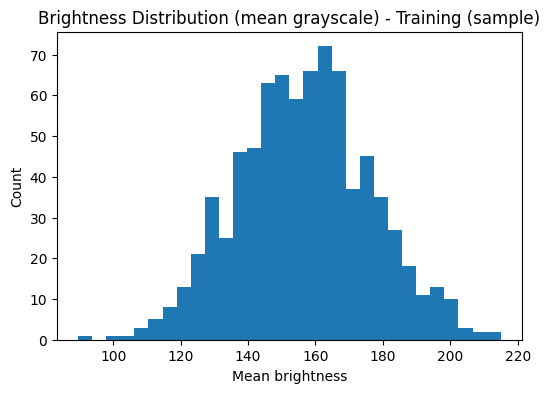

In [17]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def compute_brightness(df, sample_size=800):
    sample_df = df.sample(min(sample_size, len(df)), random_state=42)
    brightness = []

    for p in sample_df["img_path"]:
        img = cv2.imread(p)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        brightness.append(gray.mean())

    return np.array(brightness)

b_vals = compute_brightness(train_gt, sample_size=800)

plt.figure(figsize=(6,4))
plt.hist(b_vals, bins=30)
plt.title("Brightness Distribution (mean grayscale) - Training (sample)")
plt.xlabel("Mean brightness")
plt.ylabel("Count")
plt.show()

/tmp/ipykernel_1480/1200295862.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=sorted(b_class["class"].unique()))


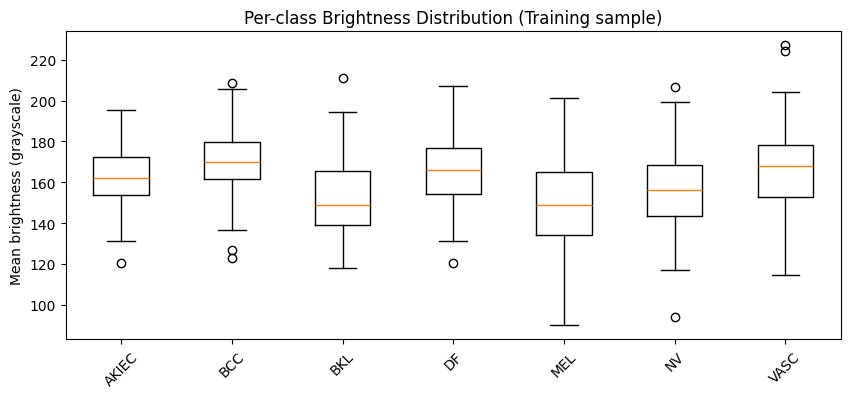

In [18]:
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

def compute_brightness_per_class(df, sample_per_class=120):
    rows = []
    for cls in df["label_name"].unique():
        sub = df[df["label_name"] == cls]
        sub = sub.sample(min(sample_per_class, len(sub)), random_state=42)
        for p in sub["img_path"]:
            img = cv2.imread(p)
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            rows.append((cls, gray.mean()))
    return pd.DataFrame(rows, columns=["class", "brightness"])

b_class = compute_brightness_per_class(train_gt, sample_per_class=120)

plt.figure(figsize=(10,4))
data = [b_class[b_class["class"]==c]["brightness"].values for c in sorted(b_class["class"].unique())]
plt.boxplot(data, labels=sorted(b_class["class"].unique()))
plt.title("Per-class Brightness Distribution (Training sample)")
plt.ylabel("Mean brightness (grayscale)")
plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_1480/3878590074.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=sorted(s_class["class"].unique()), showfliers=False)


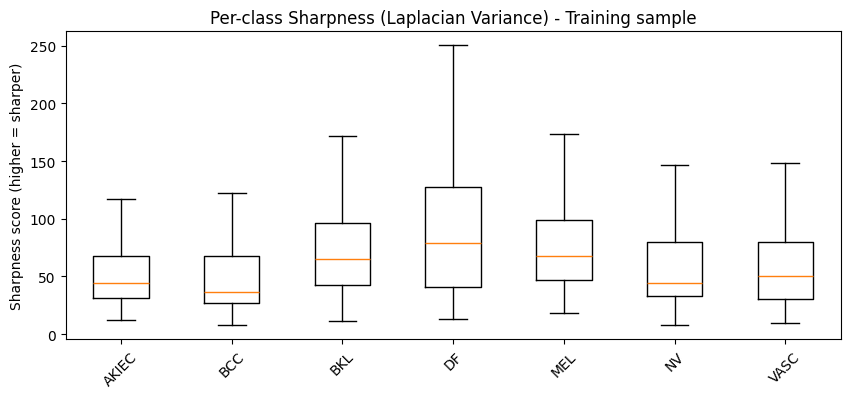

In [19]:
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

def compute_sharpness_per_class(df, sample_per_class=120):
    rows = []
    for cls in df["label_name"].unique():
        sub = df[df["label_name"] == cls]
        sub = sub.sample(min(sample_per_class, len(sub)), random_state=42)
        for p in sub["img_path"]:
            img = cv2.imread(p)
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            sharpness = cv2.Laplacian(gray, cv2.CV_64F).var()
            rows.append((cls, sharpness))
    return pd.DataFrame(rows, columns=["class", "sharpness"])

s_class = compute_sharpness_per_class(train_gt, sample_per_class=120)

plt.figure(figsize=(10,4))
data = [s_class[s_class["class"]==c]["sharpness"].values for c in sorted(s_class["class"].unique())]
plt.boxplot(data, labels=sorted(s_class["class"].unique()), showfliers=False)
plt.title("Per-class Sharpness (Laplacian Variance) - Training sample")
plt.ylabel("Sharpness score (higher = sharper)")
plt.xticks(rotation=45)
plt.show()

**Model Pipeline Setup**

In [20]:
!pip -q install timm scikit-learn tqdm

In [21]:
import os, random
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

Device: cuda


In [22]:
model_df = train_gt[["image", "img_path", "label", "label_name"]].copy()

print("model_df shape:", model_df.shape)
print(model_df.head())

model_df shape: (10015, 4)
          image                                           img_path  label  \
0  ISIC_0024306  /content/drive/MyDrive/ISIC2018_Task3/Untitled...      1   
1  ISIC_0024307  /content/drive/MyDrive/ISIC2018_Task3/Untitled...      1   
2  ISIC_0024308  /content/drive/MyDrive/ISIC2018_Task3/Untitled...      1   
3  ISIC_0024309  /content/drive/MyDrive/ISIC2018_Task3/Untitled...      1   
4  ISIC_0024310  /content/drive/MyDrive/ISIC2018_Task3/Untitled...      0   

  label_name  
0         NV  
1         NV  
2         NV  
3         NV  
4        MEL  


In [23]:
# 70% train, 30% temp
df_train, df_temp = train_test_split(
    model_df,
    test_size=0.30,
    stratify=model_df["label"],
    random_state=42
)

# Split temp into 15% val and 15% test
df_val, df_test = train_test_split(
    df_temp,
    test_size=0.50,
    stratify=df_temp["label"],
    random_state=42
)

print("Train:", df_train.shape, "Val:", df_val.shape, "Test:", df_test.shape)

# Save splits (reproducibility)
split_dir = os.path.join(BASE_DIR, "splits")
os.makedirs(split_dir, exist_ok=True)

df_train.to_csv(os.path.join(split_dir, "train_internal.csv"), index=False)
df_val.to_csv(os.path.join(split_dir, "val_internal.csv"), index=False)
df_test.to_csv(os.path.join(split_dir, "test_internal.csv"), index=False)

print("Saved splits to:", split_dir)

Train: (7010, 4) Val: (1502, 4) Test: (1503, 4)
Saved splits to: /content/drive/MyDrive/ISIC2018_Task3/splits


In [24]:
print("Train distribution:\n", df_train["label_name"].value_counts())
print("\nVal distribution:\n", df_val["label_name"].value_counts())
print("\nTest distribution:\n", df_test["label_name"].value_counts())

Train distribution:
 label_name
NV       4693
MEL       779
BKL       769
BCC       360
AKIEC     229
VASC       99
DF         81
Name: count, dtype: int64

Val distribution:
 label_name
NV       1006
MEL       167
BKL       165
BCC        77
AKIEC      49
VASC       21
DF         17
Name: count, dtype: int64

Test distribution:
 label_name
NV       1006
MEL       167
BKL       165
BCC        77
AKIEC      49
VASC       22
DF         17
Name: count, dtype: int64


**DataLoaders + Image Feature Engineering (Transforms)**

In [25]:
import torchvision.transforms as T

IMG_SIZE = 224

train_tfms = T.Compose([
    T.ToPILImage(),
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.5),
    T.RandomRotation(15),
    T.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

eval_tfms = T.Compose([
    T.ToPILImage(),
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

print("Transforms ready.")

Transforms ready.


In [26]:
import cv2
from torch.utils.data import Dataset

class ISICDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row["img_path"]
        label = int(row["label"])

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if self.transform:
            img = self.transform(img)

        return img, label

In [27]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_ds = ISICDataset(df_train, transform=train_tfms)
val_ds   = ISICDataset(df_val, transform=eval_tfms)
test_ds  = ISICDataset(df_test, transform=eval_tfms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print("Train batches:", len(train_loader))
print("Val batches  :", len(val_loader))
print("Test batches :", len(test_loader))

Train batches: 220
Val batches  : 47
Test batches : 47


**Sanity Check**

In [28]:
imgs, labels = next(iter(train_loader))
print("Batch image tensor shape:", imgs.shape)   # expected: [B, 3, 224, 224]
print("Batch labels shape:", labels.shape)       # expected: [B]
print("Labels min/max:", labels.min().item(), labels.max().item())

Batch image tensor shape: torch.Size([32, 3, 224, 224])
Batch labels shape: torch.Size([32])
Labels min/max: 0 4


**Class Imbalance Handling**

In [29]:
import numpy as np
import torch

num_classes = 7  # MEL, NV, BCC, AKIEC, BKL, DF, VASC

class_counts = df_train["label"].value_counts().sort_index().values
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * num_classes  # normalized

class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

print("Class counts:", class_counts)
print("Class weights:", class_weights)

Class counts: [ 779 4693  360  229  769   81   99]
Class weights: [0.27744086 0.04605294 0.6003512  0.94378354 0.28104867 2.66822754
 2.18309526]


**Model 1 Baseline (ResNet50)**

In [30]:
import timm
import torch.nn as nn
import torch

# Model
model = timm.create_model("resnet50", pretrained=True, num_classes=num_classes)
model = model.to(device)

# Loss with class weights (handles imbalance)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

# Optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

print("Model loaded:", "resnet50")
print("Number of classes:", num_classes)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

Model loaded: resnet50
Number of classes: 7


Training & Validation Functions

In [31]:
import numpy as np
from tqdm import tqdm
from sklearn.metrics import roc_auc_score

def one_epoch_train(model, loader, optimizer, criterion):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for imgs, labels in tqdm(loader, desc="Train", leave=False):
        imgs = imgs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += imgs.size(0)

    return running_loss / total, correct / total


@torch.no_grad()
def one_epoch_eval(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    all_probs = []
    all_true = []

    for imgs, labels in tqdm(loader, desc="Eval", leave=False):
        imgs = imgs.to(device)
        labels = labels.to(device)

        logits = model(imgs)
        loss = criterion(logits, labels)

        probs = torch.softmax(logits, dim=1).detach().cpu().numpy()
        all_probs.append(probs)
        all_true.append(labels.detach().cpu().numpy())

        running_loss += loss.item() * imgs.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += imgs.size(0)

    all_probs = np.concatenate(all_probs, axis=0)
    all_true = np.concatenate(all_true, axis=0)

    # Macro AUC (one-vs-rest)
    y_true_oh = np.eye(num_classes)[all_true]
    auc_macro = roc_auc_score(y_true_oh, all_probs, average="macro", multi_class="ovr")

    return running_loss / total, correct / total, auc_macro, all_probs, all_true

print("Training/Evaluation functions ready.")

Training/Evaluation functions ready.


In [32]:
best_auc = -1
history = []

EPOCHS = 6
save_path = os.path.join(BASE_DIR, "models", "best_resnet50.pth")

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = one_epoch_train(model, train_loader, optimizer, criterion)
    val_loss, val_acc, val_auc, val_probs, val_true = one_epoch_eval(model, val_loader, criterion)

    history.append([epoch, train_loss, train_acc, val_loss, val_acc, val_auc])

    print(f"Epoch {epoch}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} AUC: {val_auc:.4f}")

    # Save best model
    if val_auc > best_auc:
        best_auc = val_auc
        torch.save(model.state_dict(), save_path)
        print(" Saved best model with Val AUC:", round(best_auc, 4))

print("\nTraining complete. Best Val AUC:", round(best_auc, 4))
print("Best model saved at:", save_path)

Epoch 1/6 | Train Loss: 1.5581 Acc: 0.6161 | Val Loss: 1.0543 Acc: 0.6272 AUC: 0.9204
 Saved best model with Val AUC: 0.9204


Epoch 2/6 | Train Loss: 0.9913 Acc: 0.6608 | Val Loss: 0.8035 Acc: 0.6851 AUC: 0.9344
 Saved best model with Val AUC: 0.9344


Epoch 3/6 | Train Loss: 0.8247 Acc: 0.6969 | Val Loss: 0.8004 Acc: 0.6571 AUC: 0.9305


Epoch 4/6 | Train Loss: 0.6961 Acc: 0.7278 | Val Loss: 0.8137 Acc: 0.6977 AUC: 0.9396
 Saved best model with Val AUC: 0.9396


Epoch 5/6 | Train Loss: 0.5771 Acc: 0.7454 | Val Loss: 0.6457 Acc: 0.7570 AUC: 0.9569
 Saved best model with Val AUC: 0.9569


Epoch 6/6 | Train Loss: 0.5394 Acc: 0.7715 | Val Loss: 0.6703 Acc: 0.8029 AUC: 0.9642
 Saved best model with Val AUC: 0.9642

Training complete. Best Val AUC: 0.9642
Best model saved at: /content/drive/MyDrive/ISIC2018_Task3/models/best_resnet50.pth


In [33]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
import torch
import os

BASE_DIR = "/content/drive/MyDrive/ISIC2018_Task3" # Added BASE_DIR definition

# Load best saved model
best_model_path = os.path.join(BASE_DIR, "models", "best_resnet50.pth")
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

print("Loaded best model from:", best_model_path)

# Evaluate on internal test set
test_loss, test_acc, test_auc, test_probs, test_true = one_epoch_eval(model, test_loader, criterion)

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Macro AUC (OvR): {test_auc:.4f}")

Loaded best model from: /content/drive/MyDrive/ISIC2018_Task3/models/best_resnet50.pth



Test Loss: 0.7120
Test Accuracy: 0.8164
Test Macro AUC (OvR): 0.9621


Confusion Matrix:
 [[101  43   1  12   6   2   2]
 [ 55 903   9  13  22   3   1]
 [  3   1  63   7   2   1   0]
 [  0   0   7  35   5   2   0]
 [ 22  18   6  26  91   2   0]
 [  0   0   0   1   0  16   0]
 [  0   2   0   0   0   2  18]]


<Figure size 700x600 with 0 Axes>

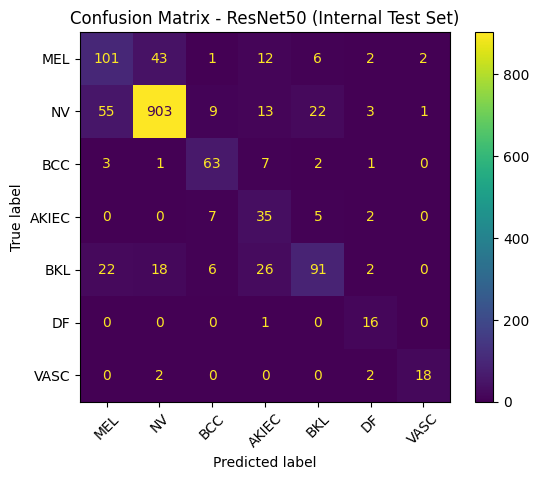


Classification Report:

              precision    recall  f1-score   support

         MEL     0.5580    0.6048    0.5805       167
          NV     0.9338    0.8976    0.9154      1006
         BCC     0.7326    0.8182    0.7730        77
       AKIEC     0.3723    0.7143    0.4895        49
         BKL     0.7222    0.5515    0.6254       165
          DF     0.5714    0.9412    0.7111        17
        VASC     0.8571    0.8182    0.8372        22

    accuracy                         0.8164      1503
   macro avg     0.6782    0.7637    0.7046      1503
weighted avg     0.8350    0.8164    0.8217      1503



In [34]:
from sklearn.metrics import confusion_matrix, classification_report

# Predicted labels
test_pred = np.argmax(test_probs, axis=1)

# Confusion Matrix
cm = confusion_matrix(test_true, test_pred)
print("Confusion Matrix:\n", cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_cols)
plt.figure(figsize=(7,6))
disp.plot(values_format="d", xticks_rotation=45)
plt.title("Confusion Matrix - ResNet50 (Internal Test Set)")
plt.show()

# Classification report
print("\nClassification Report:\n")
print(classification_report(test_true, test_pred, target_names=label_cols, digits=4))

**Model 2 Baseline (EfficientNet-B0)**

In [35]:
import timm
import torch
import torch.nn as nn

eff_model_name = "efficientnet_b0"   # fast + strong baseline

eff_model = timm.create_model(eff_model_name, pretrained=True, num_classes=num_classes)
eff_model = eff_model.to(device)

eff_criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
eff_optimizer = torch.optim.AdamW(eff_model.parameters(), lr=3e-4, weight_decay=1e-4)

print("EfficientNet model loaded:", eff_model_name)
print("Number of classes:", num_classes)

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

EfficientNet model loaded: efficientnet_b0
Number of classes: 7


In [36]:
best_eff_auc = -1
eff_history = []

EFF_EPOCHS = 6
eff_save_path = os.path.join(BASE_DIR, "models", "best_efficientnet_b0.pth")

for epoch in range(1, EFF_EPOCHS + 1):
    tr_loss, tr_acc = one_epoch_train(eff_model, train_loader, eff_optimizer, eff_criterion)
    va_loss, va_acc, va_auc, va_probs, va_true = one_epoch_eval(eff_model, val_loader, eff_criterion)

    eff_history.append([epoch, tr_loss, tr_acc, va_loss, va_acc, va_auc])

    print(f"Epoch {epoch}/{EFF_EPOCHS} | "
          f"Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | "
          f"Val Loss: {va_loss:.4f} Acc: {va_acc:.4f} AUC: {va_auc:.4f}")

    if va_auc > best_eff_auc:
        best_eff_auc = va_auc
        torch.save(eff_model.state_dict(), eff_save_path)
        print(" Saved best EfficientNet with Val AUC:", round(best_eff_auc, 4))

print("\nEfficientNet training complete. Best Val AUC:", round(best_eff_auc, 4))
print("Best EfficientNet saved at:", eff_save_path)

Epoch 1/6 | Train Loss: 1.4105 Acc: 0.5606 | Val Loss: 0.9993 Acc: 0.6871 AUC: 0.9277
 Saved best EfficientNet with Val AUC: 0.9277


Epoch 2/6 | Train Loss: 0.7498 Acc: 0.7011 | Val Loss: 0.8541 Acc: 0.7463 AUC: 0.9486
 Saved best EfficientNet with Val AUC: 0.9486


Epoch 3/6 | Train Loss: 0.6107 Acc: 0.7425 | Val Loss: 0.8240 Acc: 0.6917 AUC: 0.9461


Epoch 4/6 | Train Loss: 0.5286 Acc: 0.7675 | Val Loss: 0.6943 Acc: 0.7503 AUC: 0.9577
 Saved best EfficientNet with Val AUC: 0.9577


Epoch 5/6 | Train Loss: 0.4053 Acc: 0.8063 | Val Loss: 0.8474 Acc: 0.7497 AUC: 0.9481


Epoch 6/6 | Train Loss: 0.4104 Acc: 0.8116 | Val Loss: 0.7519 Acc: 0.7989 AUC: 0.9618
 Saved best EfficientNet with Val AUC: 0.9618

EfficientNet training complete. Best Val AUC: 0.9618
Best EfficientNet saved at: /content/drive/MyDrive/ISIC2018_Task3/models/best_efficientnet_b0.pth


In [37]:
import torch
import numpy as np

eff_best_path = os.path.join(BASE_DIR, "models", "best_efficientnet_b0.pth")
eff_model.load_state_dict(torch.load(eff_best_path, map_location=device))
eff_model.eval()

print("Loaded best EfficientNet from:", eff_best_path)

test_loss_e, test_acc_e, test_auc_e, test_probs_e, test_true_e = one_epoch_eval(
    eff_model, test_loader, eff_criterion
)

print(f"\nEfficientNet Test Loss: {test_loss_e:.4f}")
print(f"EfficientNet Test Accuracy: {test_acc_e:.4f}")
print(f"EfficientNet Test Macro AUC (OvR): {test_auc_e:.4f}")

Loaded best EfficientNet from: /content/drive/MyDrive/ISIC2018_Task3/models/best_efficientnet_b0.pth



EfficientNet Test Loss: 0.6244
EfficientNet Test Accuracy: 0.7778
EfficientNet Test Macro AUC (OvR): 0.9646


EfficientNet Confusion Matrix:
 [[111  25   7   7  11   1   5]
 [131 808  18  11  33   2   3]
 [  0   2  69   2   4   0   0]
 [  1   0  10  34   4   0   0]
 [ 25  11   4  14 111   0   0]
 [  0   1   1   1   0  14   0]
 [  0   0   0   0   0   0  22]]


<Figure size 700x600 with 0 Axes>

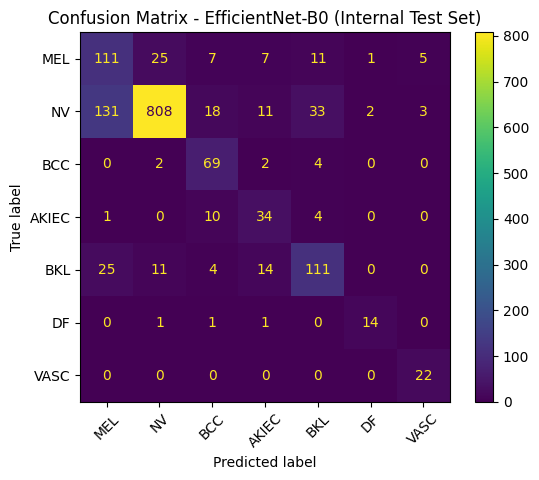


EfficientNet Classification Report:

              precision    recall  f1-score   support

         MEL     0.4142    0.6647    0.5103       167
          NV     0.9540    0.8032    0.8721      1006
         BCC     0.6330    0.8961    0.7419        77
       AKIEC     0.4928    0.6939    0.5763        49
         BKL     0.6810    0.6727    0.6768       165
          DF     0.8235    0.8235    0.8235        17
        VASC     0.7333    1.0000    0.8462        22

    accuracy                         0.7778      1503
   macro avg     0.6760    0.7934    0.7210      1503
weighted avg     0.8278    0.7778    0.7932      1503



In [38]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

test_pred_e = np.argmax(test_probs_e, axis=1)

cm_e = confusion_matrix(test_true_e, test_pred_e)
print("EfficientNet Confusion Matrix:\n", cm_e)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_e, display_labels=label_cols)
plt.figure(figsize=(7,6))
disp.plot(values_format="d", xticks_rotation=45)
plt.title("Confusion Matrix - EfficientNet-B0 (Internal Test Set)")
plt.show()

print("\nEfficientNet Classification Report:\n")
print(classification_report(test_true_e, test_pred_e, target_names=label_cols, digits=4))

Model Comparison + Select Best

             Model  Test_Accuracy  Test_MacroAUC  Macro_F1
0         ResNet50         0.8164         0.9621    0.7046
1  EfficientNet-B0         0.7778         0.9646    0.7210
Saved: /content/drive/MyDrive/ISIC2018_Task3/outputs/model_comparison.csv


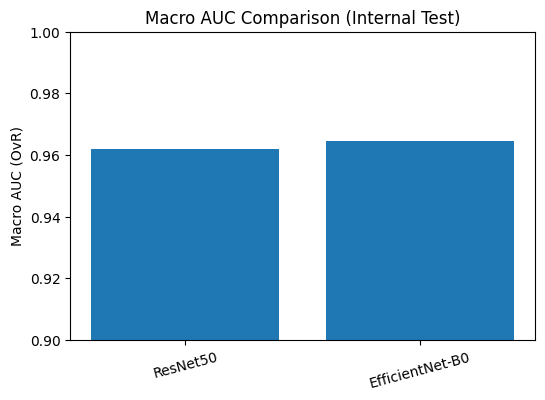

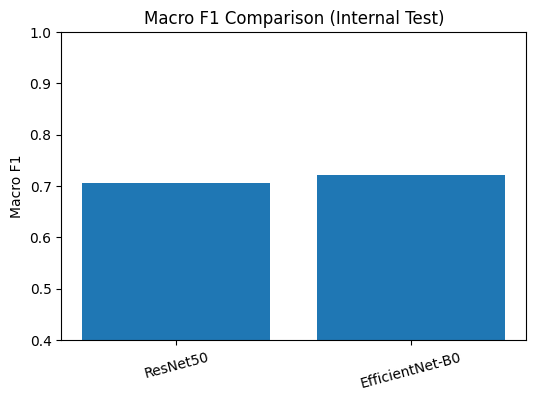

In [39]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.DataFrame([
    {"Model":"ResNet50",        "Test_Accuracy":0.8164, "Test_MacroAUC":0.9621, "Macro_F1":0.7046},
    {"Model":"EfficientNet-B0", "Test_Accuracy":0.7778, "Test_MacroAUC":0.9646, "Macro_F1":0.7210},
])

print(results)

# Save to Drive
results.to_csv(os.path.join(BASE_DIR, "outputs", "model_comparison.csv"), index=False)
print("Saved:", os.path.join(BASE_DIR, "outputs", "model_comparison.csv"))

# Simple plots
plt.figure(figsize=(6,4))
plt.bar(results["Model"], results["Test_MacroAUC"])
plt.title("Macro AUC Comparison (Internal Test)")
plt.ylabel("Macro AUC (OvR)")
plt.ylim(0.90, 1.0)
plt.xticks(rotation=15)
plt.show()

plt.figure(figsize=(6,4))
plt.bar(results["Model"], results["Macro_F1"])
plt.title("Macro F1 Comparison (Internal Test)")
plt.ylabel("Macro F1")
plt.ylim(0.40, 1.0)
plt.xticks(rotation=15)
plt.show()

In [40]:
BEST_MODEL = "EfficientNet-B0"
print("Selected BEST_MODEL:", BEST_MODEL)

Selected BEST_MODEL: EfficientNet-B0


In [41]:
import torch
import numpy as np
from tqdm import tqdm

@torch.no_grad()
def get_logits_and_labels(model, loader):
    model.eval()
    all_logits, all_labels = [], []
    for imgs, labels in tqdm(loader, desc="Collect logits", leave=False):
        imgs = imgs.to(device)
        labels = labels.to(device)
        logits = model(imgs)
        all_logits.append(logits.detach().cpu().numpy())
        all_labels.append(labels.detach().cpu().numpy())
    return np.concatenate(all_logits), np.concatenate(all_labels)

In [42]:
import os

eff_best_path = os.path.join(BASE_DIR, "models", "best_efficientnet_b0.pth")
eff_model.load_state_dict(torch.load(eff_best_path, map_location=device))
eff_model.eval()

val_logits, val_y = get_logits_and_labels(eff_model, val_loader)
test_logits, test_y = get_logits_and_labels(eff_model, test_loader)

print("VAL logits shape:", val_logits.shape, "VAL labels:", val_y.shape)
print("TEST logits shape:", test_logits.shape, "TEST labels:", test_y.shape)

VAL logits shape: (1502, 7) VAL labels: (1502,)
TEST logits shape: (1503, 7) TEST labels: (1503,)


ECE (VAL) before: 0.0796
ECE (TEST) before: 0.0952


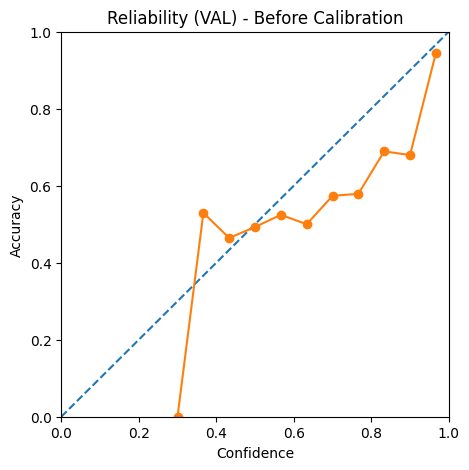

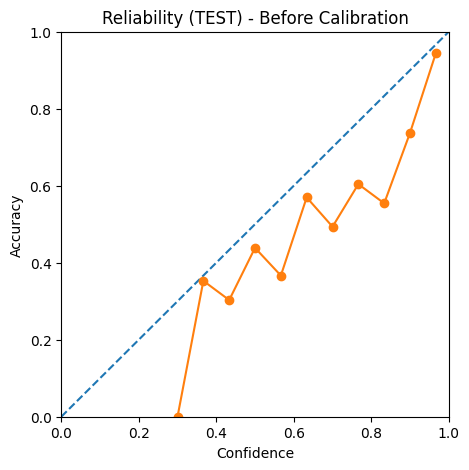

In [43]:
import numpy as np
import matplotlib.pyplot as plt

def softmax_np(x):
    x = x - x.max(axis=1, keepdims=True)
    exp = np.exp(x)
    return exp / exp.sum(axis=1, keepdims=True)

def ece_score(probs, y_true, n_bins=15):
    conf = probs.max(axis=1)
    pred = probs.argmax(axis=1)
    acc  = (pred == y_true).astype(float)

    bins = np.linspace(0, 1, n_bins+1)
    ece = 0.0
    for i in range(n_bins):
        mask = (conf > bins[i]) & (conf <= bins[i+1])
        if mask.sum() == 0:
            continue
        ece += (mask.sum()/len(y_true)) * abs(acc[mask].mean() - conf[mask].mean())
    return ece

def plot_reliability(probs, y_true, n_bins=15, title="Reliability Diagram"):
    conf = probs.max(axis=1)
    pred = probs.argmax(axis=1)
    acc  = (pred == y_true).astype(float)

    bins = np.linspace(0, 1, n_bins+1)
    centers = (bins[:-1] + bins[1:]) / 2
    bin_acc = []

    for i in range(n_bins):
        mask = (conf > bins[i]) & (conf <= bins[i+1])
        bin_acc.append(acc[mask].mean() if mask.sum() > 0 else np.nan)

    plt.figure(figsize=(5,5))
    plt.plot([0,1],[0,1],"--")
    plt.plot(centers, bin_acc, marker="o")
    plt.title(title)
    plt.xlabel("Confidence")
    plt.ylabel("Accuracy")
    plt.xlim(0,1); plt.ylim(0,1)
    plt.show()

val_probs = softmax_np(val_logits)
test_probs = softmax_np(test_logits)

print("ECE (VAL) before:", round(ece_score(val_probs, val_y), 4))
print("ECE (TEST) before:", round(ece_score(test_probs, test_y), 4))

plot_reliability(val_probs, val_y, title="Reliability (VAL) - Before Calibration")
plot_reliability(test_probs, test_y, title="Reliability (TEST) - Before Calibration")

Temperature Scaling

In [44]:
import torch
import torch.nn as nn

class TemperatureScaler(nn.Module):
    def __init__(self):
        super().__init__()
        self.temperature = nn.Parameter(torch.ones(1) * 1.0)

    def forward(self, logits):
        return logits / self.temperature

def fit_temperature(val_logits_np, val_y_np):
    logits = torch.tensor(val_logits_np, dtype=torch.float32).to(device)
    y = torch.tensor(val_y_np, dtype=torch.long).to(device)

    scaler = TemperatureScaler().to(device)
    nll = nn.CrossEntropyLoss()
    optimizer = torch.optim.LBFGS([scaler.temperature], lr=0.1, max_iter=50)

    def closure():
        optimizer.zero_grad()
        loss = nll(scaler(logits), y)
        loss.backward()
        return loss

    optimizer.step(closure)
    return scaler

scaler = fit_temperature(val_logits, val_y)
print("Learned temperature:", float(scaler.temperature.detach().cpu().numpy()))

Learned temperature: 1.7288997173309326


/tmp/ipykernel_1480/663162298.py:30: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print("Learned temperature:", float(scaler.temperature.detach().cpu().numpy()))


ECE (VAL) after: 0.0333
ECE (TEST) after: 0.0267


/tmp/ipykernel_1480/2880465469.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  T_val = float(scaler.temperature.detach().cpu().numpy())


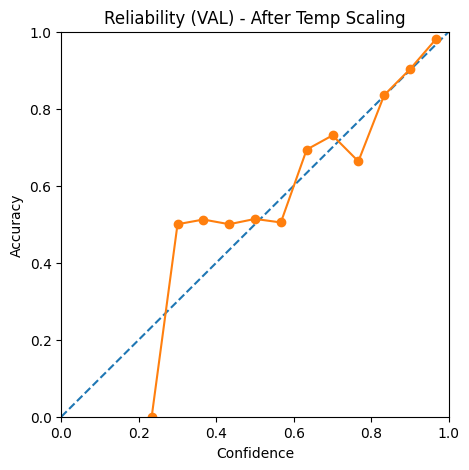

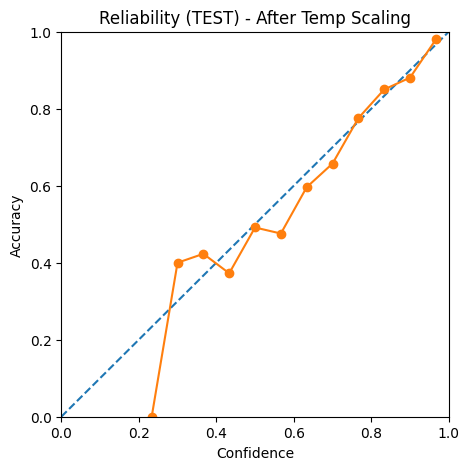

In [45]:
T_val = float(scaler.temperature.detach().cpu().numpy())

val_logits_cal  = val_logits / T_val
test_logits_cal = test_logits / T_val

val_probs_cal  = softmax_np(val_logits_cal)
test_probs_cal = softmax_np(test_logits_cal)

print("ECE (VAL) after:", round(ece_score(val_probs_cal, val_y), 4))
print("ECE (TEST) after:", round(ece_score(test_probs_cal, test_y), 4))

plot_reliability(val_probs_cal, val_y, title="Reliability (VAL) - After Temp Scaling")
plot_reliability(test_probs_cal, test_y, title="Reliability (TEST) - After Temp Scaling")

Grad-CAM (EfficientNet-B0)

In [46]:
import torch
import numpy as np

eff_best_path = os.path.join(BASE_DIR, "models", "best_efficientnet_b0.pth")
eff_model.load_state_dict(torch.load(eff_best_path, map_location=device))
eff_model.eval()

label_names = label_cols  # ['MEL','NV','BCC','AKIEC','BKL','DF','VASC']
print("Label order:", label_names)

Label order: ['MEL', 'NV', 'BCC', 'AKIEC', 'BKL', 'DF', 'VASC']


In [47]:
import random


test_logits, test_y = get_logits_and_labels(eff_model, test_loader)
test_probs = softmax_np(test_logits)
test_pred = test_probs.argmax(axis=1)

correct_idx = np.where(test_pred == test_y)[0].tolist()
wrong_idx   = np.where(test_pred != test_y)[0].tolist()

print("Correct samples:", len(correct_idx))
print("Wrong samples:", len(wrong_idx))

# Pick 4 correct + 4 wrong
random.seed(42)
pick_correct = random.sample(correct_idx, 4)
pick_wrong   = random.sample(wrong_idx, 4)

selected_indices = pick_correct + pick_wrong
print("Selected indices:", selected_indices)

Correct samples: 1169
Wrong samples: 334
Selected indices: [285, 55, 706, 632, 544, 339, 269, 1306]


In [48]:
import cv2
import matplotlib.pyplot as plt
import torch.nn.functional as F

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, inp, out):
        self.activations = out

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, input_tensor, class_idx=None):
        self.model.zero_grad()
        logits = self.model(input_tensor)

        if class_idx is None:
            class_idx = logits.argmax(dim=1).item()

        score = logits[:, class_idx]
        score.backward(retain_graph=True)

        grads = self.gradients
        acts = self.activations

        weights = grads.mean(dim=(2,3), keepdim=True)
        cam = (weights * acts).sum(dim=1, keepdim=True)
        cam = F.relu(cam)

        cam = cam.squeeze().detach().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, class_idx

In [49]:
target_layer = eff_model.conv_head
cam_generator = GradCAM(eff_model, target_layer)
print("GradCAM target layer set:", target_layer)

GradCAM target layer set: Conv2d(320, 1280, kernel_size=(1, 1), stride=(1, 1), bias=False)


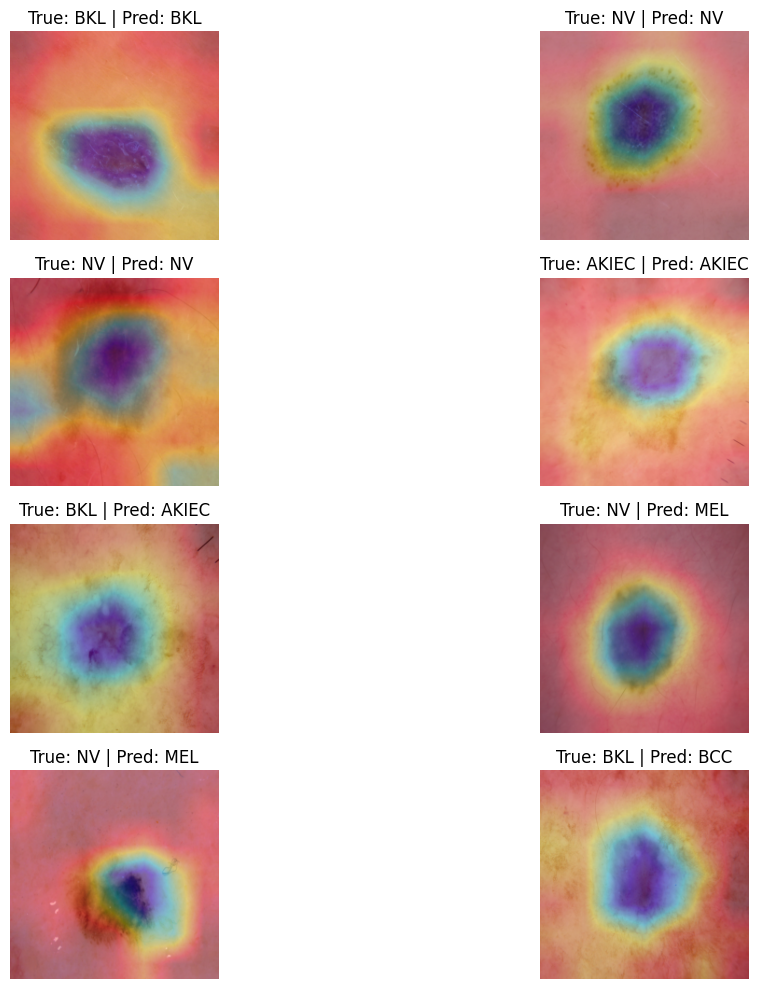

In [50]:
def denormalize(img_tensor):
    # img_tensor: [3,H,W]
    mean = np.array([0.485, 0.456, 0.406]).reshape(3,1,1)
    std  = np.array([0.229, 0.224, 0.225]).reshape(3,1,1)
    img = img_tensor.cpu().numpy()
    img = (img * std) + mean
    img = np.clip(img, 0, 1)
    img = (img.transpose(1,2,0) * 255).astype(np.uint8)
    return img


df_test_reset = df_test.reset_index(drop=True)

plt.figure(figsize=(14,10))

for i, idx in enumerate(selected_indices, 1):
    img_path = df_test_reset.loc[idx, "img_path"]
    true_lab = int(df_test_reset.loc[idx, "label"])

    # read image using cv2 and apply eval transforms
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_t = eval_tfms(img).unsqueeze(0).to(device)

    cam, pred_class = cam_generator.generate(img_t, class_idx=None)

    # resize cam to image size
    cam_resized = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
    heatmap = cv2.applyColorMap((cam_resized*255).astype(np.uint8), cv2.COLORMAP_JET)

    img_show = denormalize(img_t.squeeze(0))
    overlay = cv2.addWeighted(img_show, 0.65, heatmap, 0.35, 0)

    plt.subplot(4, 2, i)
    plt.imshow(overlay)
    plt.axis("off")
    plt.title(f"True: {label_names[true_lab]} | Pred: {label_names[pred_class]}")

plt.tight_layout()
plt.show()

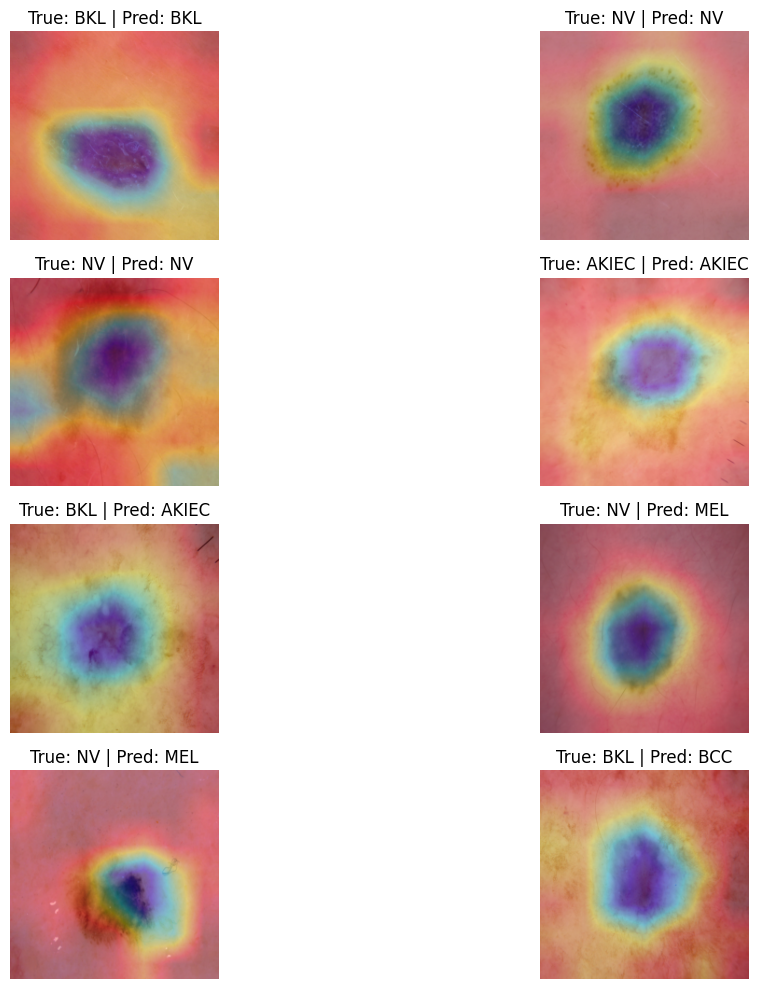

Saved Grad-CAM panel to: /content/drive/MyDrive/ISIC2018_Task3/outputs/gradcam_panel_effnetb0.png


In [51]:
import os
import matplotlib.pyplot as plt

out_path = os.path.join(BASE_DIR, "outputs", "gradcam_panel_effnetb0.png")

plt.figure(figsize=(14,10))

for i, idx in enumerate(selected_indices, 1):
    img_path = df_test_reset.loc[idx, "img_path"]
    true_lab = int(df_test_reset.loc[idx, "label"])

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_t = eval_tfms(img).unsqueeze(0).to(device)

    cam, pred_class = cam_generator.generate(img_t, class_idx=None)
    cam_resized = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
    heatmap = cv2.applyColorMap((cam_resized*255).astype(np.uint8), cv2.COLORMAP_JET)

    img_show = denormalize(img_t.squeeze(0))
    overlay = cv2.addWeighted(img_show, 0.65, heatmap, 0.35, 0)

    plt.subplot(4, 2, i)
    plt.imshow(overlay)
    plt.axis("off")
    plt.title(f"True: {label_names[true_lab]} | Pred: {label_names[pred_class]}")

plt.tight_layout()
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved Grad-CAM panel to:", out_path)

In [52]:
import pandas as pd
import numpy as np

rows = []
for idx in selected_indices:
    rows.append({
        "index": idx,
        "image": df_test_reset.loc[idx, "image"],
        "img_path": df_test_reset.loc[idx, "img_path"],
        "true_label": label_names[int(df_test_reset.loc[idx, "label"])],
        "pred_label": label_names[int(test_pred[idx])]
    })

gradcam_cases = pd.DataFrame(rows)
cases_path = os.path.join(BASE_DIR, "outputs", "gradcam_cases.csv")
gradcam_cases.to_csv(cases_path, index=False)

print(gradcam_cases)
print("Saved:", cases_path)

   index         image                                           img_path  \
0    285  ISIC_0027167  /content/drive/MyDrive/ISIC2018_Task3/Untitled...   
1     55  ISIC_0025555  /content/drive/MyDrive/ISIC2018_Task3/Untitled...   
2    706  ISIC_0027618  /content/drive/MyDrive/ISIC2018_Task3/Untitled...   
3    632  ISIC_0024579  /content/drive/MyDrive/ISIC2018_Task3/Untitled...   
4    544  ISIC_0025326  /content/drive/MyDrive/ISIC2018_Task3/Untitled...   
5    339  ISIC_0034178  /content/drive/MyDrive/ISIC2018_Task3/Untitled...   
6    269  ISIC_0030773  /content/drive/MyDrive/ISIC2018_Task3/Untitled...   
7   1306  ISIC_0026539  /content/drive/MyDrive/ISIC2018_Task3/Untitled...   

  true_label pred_label  
0        BKL        BKL  
1         NV         NV  
2         NV         NV  
3      AKIEC      AKIEC  
4        BKL      AKIEC  
5         NV        MEL  
6         NV        MEL  
7        BKL        BCC  
Saved: /content/drive/MyDrive/ISIC2018_Task3/outputs/gradcam_cases.csv


Robustness Tests

In [53]:
import cv2
import numpy as np
import torch
from sklearn.metrics import roc_auc_score
from tqdm import tqdm

# ---------- Perturbations ----------
def apply_brightness(img, factor=1.25):
    # img: uint8 RGB
    out = np.clip(img.astype(np.float32) * factor, 0, 255).astype(np.uint8)
    return out

def apply_blur(img, k=5):
    return cv2.GaussianBlur(img, (k, k), 0)

def apply_rotation(img, angle=15):
    h, w = img.shape[:2]
    M = cv2.getRotationMatrix2D((w//2, h//2), angle, 1.0)
    return cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REFLECT)

# ---------- Helper: numpy softmax ----------
def softmax_np(x):
    x = x - x.max(axis=1, keepdims=True)
    ex = np.exp(x)
    return ex / ex.sum(axis=1, keepdims=True)

# ---------- Robust evaluation ----------
@torch.no_grad()
def eval_under_perturbation(df, perturb_fn=None):
    eff_model.eval()

    all_probs = []
    all_true = []

    for i in tqdm(range(len(df)), desc="Robust eval", leave=False):
        img_path = df.loc[i, "img_path"]
        y = int(df.loc[i, "label"])

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if perturb_fn is not None:
            img = perturb_fn(img)

        x = eval_tfms(img).unsqueeze(0).to(device)
        logits = eff_model(x)
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]

        all_probs.append(probs)
        all_true.append(y)

    all_probs = np.array(all_probs)
    all_true = np.array(all_true)

    pred = all_probs.argmax(axis=1)
    acc = (pred == all_true).mean()

    y_true_oh = np.eye(len(label_cols))[all_true]
    auc_macro = roc_auc_score(y_true_oh, all_probs, average="macro", multi_class="ovr")

    return acc, auc_macro

print("Robustness helper functions ready.")

Robustness helper functions ready.


In [54]:
import pandas as pd
import os

df_test_reset = df_test.reset_index(drop=True)

base_acc, base_auc = eval_under_perturbation(df_test_reset, None)
bright_acc, bright_auc = eval_under_perturbation(df_test_reset, lambda im: apply_brightness(im, 1.25))
blur_acc, blur_auc     = eval_under_perturbation(df_test_reset, lambda im: apply_blur(im, 5))
rot_acc, rot_auc       = eval_under_perturbation(df_test_reset, lambda im: apply_rotation(im, 15))

robust_df = pd.DataFrame([
    {"Condition":"Original", "Accuracy":base_acc, "MacroAUC":base_auc},
    {"Condition":"Brightness x1.25", "Accuracy":bright_acc, "MacroAUC":bright_auc},
    {"Condition":"GaussianBlur k=5", "Accuracy":blur_acc, "MacroAUC":blur_auc},
    {"Condition":"Rotation 15deg", "Accuracy":rot_acc, "MacroAUC":rot_auc},
])

print(robust_df)

robust_path = os.path.join(BASE_DIR, "outputs", "robustness_results.csv")
robust_df.to_csv(robust_path, index=False)
print("Saved:", robust_path)

          Condition  Accuracy  MacroAUC
0          Original  0.777778  0.964550
1  Brightness x1.25  0.753160  0.946605
2  GaussianBlur k=5  0.740519  0.946697
3    Rotation 15deg  0.767132  0.956247
Saved: /content/drive/MyDrive/ISIC2018_Task3/outputs/robustness_results.csv


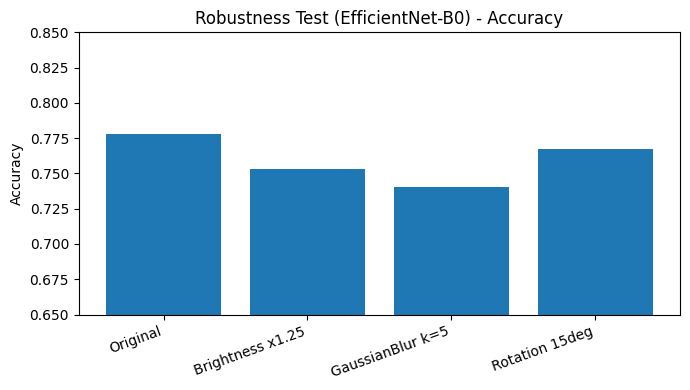

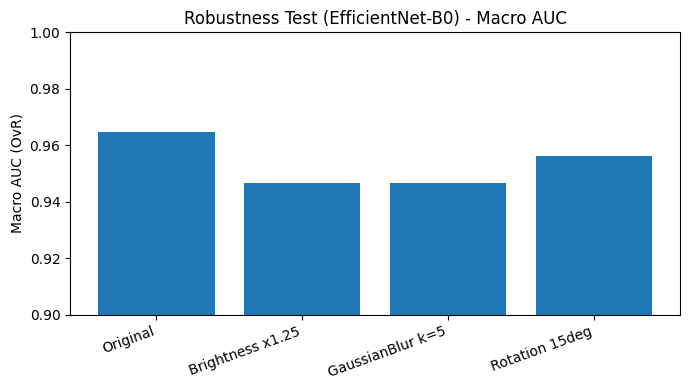

Saved plots:
/content/drive/MyDrive/ISIC2018_Task3/outputs/robustness_barplot.png
/content/drive/MyDrive/ISIC2018_Task3/outputs/robustness_auc_barplot.png


In [55]:
import matplotlib.pyplot as plt
import os

robust_plot_path = os.path.join(BASE_DIR, "outputs", "robustness_barplot.png")

plt.figure(figsize=(7,4))
plt.bar(robust_df["Condition"], robust_df["Accuracy"])
plt.title("Robustness Test (EfficientNet-B0) - Accuracy")
plt.ylabel("Accuracy")
plt.xticks(rotation=20, ha="right")
plt.ylim(0.65, 0.85)
plt.tight_layout()
plt.savefig(robust_plot_path, dpi=300, bbox_inches="tight")
plt.show()

robust_plot_path2 = os.path.join(BASE_DIR, "outputs", "robustness_auc_barplot.png")

plt.figure(figsize=(7,4))
plt.bar(robust_df["Condition"], robust_df["MacroAUC"])
plt.title("Robustness Test (EfficientNet-B0) - Macro AUC")
plt.ylabel("Macro AUC (OvR)")
plt.xticks(rotation=20, ha="right")
plt.ylim(0.90, 1.0)
plt.tight_layout()
plt.savefig(robust_plot_path2, dpi=300, bbox_inches="tight")
plt.show()

print("Saved plots:")
print(robust_plot_path)
print(robust_plot_path2)